# Webinar 33 (Sprint 15) — Proyecto de Series de Tiempo (70 min)

**Objetivo:** predecir la demanda por hora (o el valor temporal) usando el dataset `taxi.csv`, aplicando un flujo completo:
limpieza → re-muestreo → ingeniería de características → validación con **TimeSeriesSplit** → modelado → evaluación (RMSE) → forecast multi‑paso.

**Dataset cargado:** `taxi.csv` con **26496 filas** y **2 columnas**  
**Columnas detectadas:** datetime, num_orders

**Heurística detectada**:
- Columna temporal candidata: `[datetime]` (parseo OK)
- Columna objetivo candidata: `[num_orders]`

---

## Agenda (70 minutos)

**0–5 min — Contexto del problema**
- Qué es una serie de tiempo, estacionalidad, tendencia, ruido, fuga de datos.
- Métrica principal: **RMSE**.

**5–15 min — Carga y EDA mínimo**
- Parseo de fechas, ordenamiento, índice temporal, frecuencia horaria.
- Gaps & Missing: detectar y **completar el calendario**.

**15–25 min — Re-muestreo y features**
- Re-muestrear a 1H si aplica, crear lags y medias móviles (3h, 24h, 168h).
- Features de calendario (hora, día de la semana, fin de semana).

**25–35 min — Split temporal y baseline**
- **Train / Valid / Test** por tiempo (ej. 80/10/10).
- Baselines: valor previo, media móvil. Calcular **RMSE** de referencia.

**35–55 min — Modelado**
- `LinearRegression` con lags + rolling stats.
- `RandomForestRegressor` con **TimeSeriesSplit** para búsqueda simple.

**55–65 min — Evaluación y forecast**
- Comparar modelos en **valid** y **test**.  
- Re-entrenar en **train+valid**, **forecast 24h** recursivo.

**65–70 min — Cierre**
- Checklist anti-fugas, conclusiones, mejoras y tareas.


## Objetivos de aprendizaje

1. Preparar series temporales correctamente (índice, frecuencia y calendario completo).
2. Diseñar baselines fuertes y medirlos con RMSE.
3. Crear características relevantes: lags, rolling windows y calendarios.
4. Validar sin fuga de datos con `TimeSeriesSplit` y cortes por tiempo.
5. Comparar y seleccionar un modelo; generar un **forecast multi‑paso**.
6. Documentar supuestos y *pitfalls* (datos faltantes, *leakage*, *target snooping*).


> **Nota:** Este cuaderno incluye explicaciones *antes de cada celda de código* para que puedas narrar la clase paso a paso.

## 1) Carga del dataset e inspección

**Qué haremos y por qué:**  
- Leer `taxi.csv`.
- Detectar y **parsear** la columna de fechas (`datetime` detectada heurísticamente).
- Ordenar por tiempo y establecer índice temporal.
- Confirmar periodicidad horaria; si no, **re-muestrear** a 1H y completar huecos.


In [30]:
# --- Imports mínimos ---
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [36]:
# --- Config editable ---
DATE_COL = "datetime"
TARGET_COL = "num_orders"
DATA_PATH = Path("taxi.csv")

# --- Carga y preparación básica ---
# 1) Leer y parsear fecha
df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])

df.head()

,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32


In [37]:
# 2) Ordenar e indexar por tiempo
df = df.sort_values(DATE_COL).set_index(DATE_COL)

In [38]:
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [39]:
# 3) Re-muestrear a 1H (completa calendario y suma si hay múltiples filas por hora)
df_res = df.resample("H").sum(numeric_only=True)

In [40]:
# 4) Comprobación de la columna objetivo
# assert TARGET_COL in df.columns, f"No se encuentra '{TARGET_COL}'. Columnas: {list(df.columns)}"

In [41]:
# 5) Relleno simple de huecos en el objetivo (conteos → 0)
df[TARGET_COL] = df[TARGET_COL].fillna(0)

In [42]:
print("Rango temporal:", df.index.min(), "→", df.index.max())
df.head(3)

Rango temporal: 2018-03-01 00:00:00 → 2018-08-31 23:50:00


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28


### EDA mínimo y chequeos

- `info()` para verificar tipos y nulos.  
- Duplicados temporales.  
- Valores negativos/atípicos en la variable objetivo.  
- Visualización de la serie y medias móviles (no fijar estilos/colores).


In [43]:
# --- EDA ---
print(df_res.info())
dups = df_res.index.duplicated().sum()
print("Duplicados de índice temporal:", dups)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB
None
Duplicados de índice temporal: 0


In [24]:
desc = df_res.describe()
print(desc)

        num_orders
count  4416.000000
mean     84.422781
std      45.023853
min       0.000000
25%      54.000000
50%      78.000000
75%     107.000000
max     462.000000


In [44]:
# Chequeo rápido de negativos
neg_ratio = (df_res['num_orders'] < 0).mean()
print(f"Proporción de valores negativos en '{'num_orders'}': {neg_ratio:.4f}")

Proporción de valores negativos en 'num_orders': 0.0000


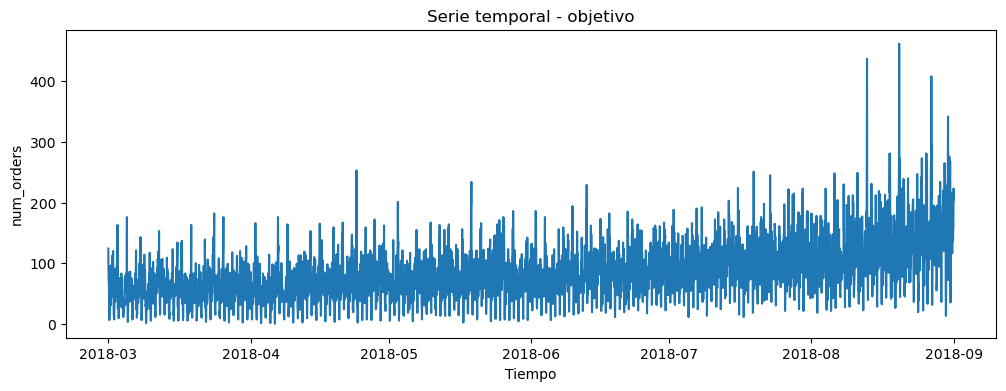

In [45]:
# Visualización básica
plt.figure(figsize=(12,4))
plt.plot(df_res.index, df_res['num_orders'])
plt.title("Serie temporal - objetivo")
plt.xlabel("Tiempo")
plt.ylabel('num_orders')
plt.show()

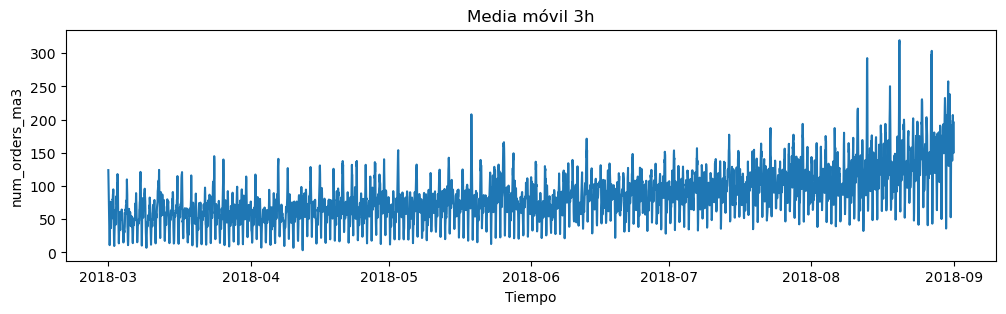

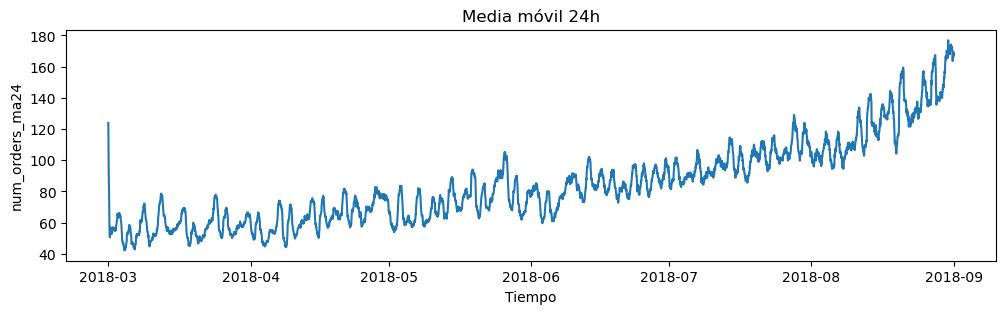

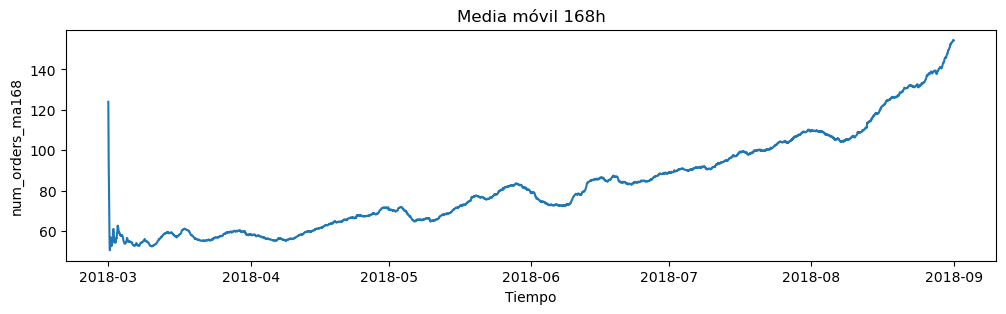

In [27]:
# Medias móviles
for w in [3, 24, 168]:
    plt.figure(figsize=(12,3))
    plt.plot(df_res.index, df_res['num_orders'].rolling(w, min_periods=1).mean())
    plt.title(f"Media móvil {w}h")
    plt.xlabel("Tiempo")
    plt.ylabel(f"{'num_orders'}_ma{w}")
    plt.show()

## 2) Ingeniería de características

**Qué haremos y por qué:**  
- **Lags** (1, 2, 3, 24): capturan dependencia temporal.  
- **Rolling stats**: medias móviles y desviación (3h, 24h, 168h).  
- **Calendario**: hora del día, día de la semana, fin de semana.  
- Evitamos incluir el valor actual del target para no generar **fuga**.


In [13]:
target_col = 'num_orders'

In [46]:
df_res.head()

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


In [47]:
# --- Funciones para features ---
def make_features(df_ts, target, lags=(1,2,3,24), roll_windows=(3,24,168)):
    df_feat = pd.DataFrame(index=df_ts.index)
    df_feat[target] = df_ts[target]

    # Lags
    for l in lags:
        df_feat[f"{target}_lag{l}"] = df_ts[target].shift(l)

    # Rolling stats
    for w in roll_windows:
        df_feat[f"{target}_ma{w}"] = df_ts[target].shift(1).rolling(w).mean()
        df_feat[f"{target}_std{w}"] = df_ts[target].shift(1).rolling(w).std()

    # Calendario
    df_feat["hour"] = df_ts.index.hour
    df_feat["dow"] = df_ts.index.dayofweek
    df_feat["is_weekend"] = (df_feat["dow"] >= 5).astype(int)

    return df_feat

df_feat = make_features(df_res, target_col)
df_feat = df_feat.dropna()  # perderemos las primeras filas por lags/rolling
print("Shape con features:", df_feat.shape)
df_feat.head(3)


Shape con features: (4248, 14)


,num_orders,num_orders_lag1,num_orders_lag2,num_orders_lag3,num_orders_lag24,num_orders_ma3,num_orders_std3,num_orders_ma24,num_orders_std24,num_orders_ma168,num_orders_std168,hour,dow,is_weekend
datetime,,,,,,,,,,,,,,
2018-03-08 00:00:00,143,94.0,127.0,108.0,100.0,109.666667,16.563011,60.041667,33.200942,54.226190,29.596225,0,3,0
2018-03-08 01:00:00,78,143.0,94.0,127.0,121.0,121.333333,24.986663,61.833333,36.452073,54.339286,29.899198,1,3,0
2018-03-08 02:00:00,65,78.0,143.0,94.0,24.0,105.000000,33.867388,60.041667,34.417487,54.297619,29.861067,2,3,0


## 3) Split temporal (Train/Valid/Test) + Baselines

- Usamos cortes por tiempo: 80% train, 10% valid, 10% test (editables).  
- Baselines: **naive** (valor previo) y **media móvil** (24h).  
- Métrica: **RMSE**.


In [49]:
df_feat.columns

Index(['num_orders', 'num_orders_lag1', 'num_orders_lag2', 'num_orders_lag3',
       'num_orders_lag24', 'num_orders_ma3', 'num_orders_std3',
       'num_orders_ma24', 'num_orders_std24', 'num_orders_ma168',
       'num_orders_std168', 'hour', 'dow', 'is_weekend'],
      dtype='object')

In [51]:
# --- Split simple con train_test_split (sin mezclar) ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Columnas de features = todo menos el target
feature_cols = [c for c in df_feat.columns if c != target_col]

X = df_feat[feature_cols]
y = df_feat[target_col]

X = df_feat[['num_orders_lag1', 'num_orders_lag2', 'num_orders_lag3',
       'num_orders_lag24', 'num_orders_ma3', 'num_orders_std3',
       'num_orders_ma24', 'num_orders_std24', 'num_orders_ma168',
       'num_orders_std168', 'hour', 'dow', 'is_weekend']]
y = df_feat['num_orders']

# Split 80/20 preservando orden temporal (shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, shuffle=False
)

print("Shapes ->",
      "X_train:", X_train.shape,
      "X_test:",  X_test.shape)

# -------- Baselines rápidos en TEST --------
lag1_col = f"{target_col}_lag1"
ma24_col = f"{target_col}_ma24"

# Aseguramos que existan columnas de baseline creadas en la etapa de features
assert lag1_col in X_test.columns, f"Falta {lag1_col}; crea lags antes."
assert ma24_col in X_test.columns, f"Falta {ma24_col}; crea rolling antes."

# 1) Naive (y_hat_t = y_{t-1})
yhat_naive = X_test[lag1_col]
rmse_naive = mean_squared_error(y_test.loc[yhat_naive.index], yhat_naive, squared=False)

# 2) Media móvil 24h (descarta NaN iniciales automáticamente)
mask = ~X_test[ma24_col].isna()
rmse_ma24 = mean_squared_error(y_test[mask], X_test.loc[mask, ma24_col], squared=False)

print(f"RMSE baseline naive (test): {rmse_naive:.3f}")
print(f"RMSE baseline MA24  (test): {rmse_ma24:.3f}")

Shapes -> X_train: (3823, 13) X_test: (425, 13)
RMSE baseline naive (test): 58.820
RMSE baseline MA24  (test): 58.166


## 4) Modelado

### 4.1 LinearRegression (pipeline con escalado)
- Las lags/rolling pueden tener distintas escalas → **StandardScaler**.
- Validación con RMSE en `valid`.

### 4.2 RandomForestRegressor (búsqueda simple)
- `TimeSeriesSplit` para respetar el orden temporal.
- Pequeña malla de hiperparámetros para no alargar el *runtime*.


In [52]:
# Escalar solo con información de TRAIN (evitar leakage)
scaler = StandardScaler(with_mean=True, with_std=True)
X_train_s = scaler.fit_transform(X_train)
X_valid_s = scaler.transform(X_valid)

lin = LinearRegression()
lin.fit(X_train_s, y_train)

pred_valid_lin = lin.predict(X_valid_s)
rmse_lin = mean_squared_error(y_valid, pred_valid_lin, squared=False)
print(f"RMSE LinearRegression (valid): {rmse_lin:.3f}")

RMSE LinearRegression (valid): 36.636


In [53]:
# --- Random Forest con TSS (sin Pipeline) ---
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor

tscv = TimeSeriesSplit(n_splits=3)
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [6, 10, None],
    "min_samples_split": [2, 5]
}

gcv = GridSearchCV(
    rf,
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=0
)
gcv.fit(X_train, y_train)

best_rf = gcv.best_estimator_
pred_valid_rf = best_rf.predict(X_valid)
rmse_rf = mean_squared_error(y_valid, pred_valid_rf, squared=False)

print("Mejores hiperparámetros RF:", gcv.best_params_)
print(f"RMSE RandomForest (valid): {rmse_rf:.3f}")


Mejores hiperparámetros RF: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
RMSE RandomForest (valid): 18.273


## 5) Selección, evaluación en Test y *forecast* 24h

- Elegimos el mejor modelo en **valid**.  
- Re-entrenamos en **train+valid** y evaluamos en **test**.  
- Forecast **multi‑paso** (24h) de forma recursiva: usamos cada predicción como *lag* para la siguiente.


Mejor en valid: RandomForest (RMSE=34.283)
RMSE en TEST: 44.308


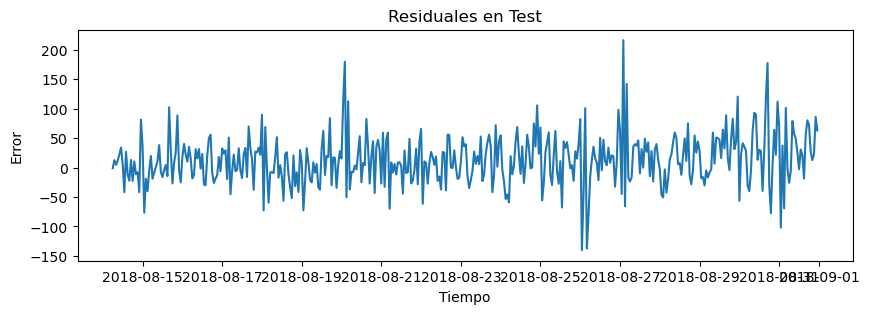

Forecast 24h (head):
                     num_orders
2018-09-01 00:00:00  195.957921
2018-09-01 01:00:00  189.783940
2018-09-01 02:00:00  192.133704
2018-09-01 03:00:00  166.924422
2018-09-01 04:00:00  153.761011


In [28]:
# ==== IMPORTS NECESARIOS ====
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# ==== SUPONE QUE YA EXISTEN: rmse_lin, rmse_rf, best_rf, X_train, y_train, X_valid, y_valid, X_test, y_test
#     y que df_res, df_feat, target_col también existen de pasos previos. ====

# ------------------------------------------------------------
# 1) Selección simple por RMSE en valid (sin guardar objetos)
# ------------------------------------------------------------
if rmse_lin <= rmse_rf:
    best_name = "LinearRegression"
    best_rmse = rmse_lin
else:
    best_name = "RandomForest"
    best_rmse = rmse_rf

print(f"Mejor en valid: {best_name} (RMSE={best_rmse:.3f})")

# ------------------------------------------------------------
# 2) Re-entrenar en TRAIN+VALID (sin Pipeline)
# ------------------------------------------------------------
X_trv = pd.concat([X_train, X_valid], axis=0)
y_trv = pd.concat([y_train, y_valid], axis=0)

final_scaler = None
final_lin = None
final_rf = None

if best_name == "LinearRegression":
    # Escalado SOLO con train+valid (coherente para evaluar en test)
    final_scaler = StandardScaler(with_mean=True, with_std=True)
    X_trv_s = final_scaler.fit_transform(X_trv)

    final_lin = LinearRegression()
    final_lin.fit(X_trv_s, y_trv)

    # Transformar test y predecir
    X_test_s = final_scaler.transform(X_test)
    pred_test = final_lin.predict(X_test_s)

else:  # RandomForest
    # Reusar hiperparámetros del mejor modelo y re-entrenar en train+valid
    final_rf = RandomForestRegressor(**best_rf.get_params())
    final_rf.fit(X_trv, y_trv)

    pred_test = final_rf.predict(X_test)

rmse_test = mean_squared_error(y_test, pred_test, squared=False)
print(f"RMSE en TEST: {rmse_test:.3f}")

# ------------------------------------------------------------
# 3) Residuales en test
# ------------------------------------------------------------
resid = y_test - pred_test
plt.figure(figsize=(10,3))
plt.plot(y_test.index, resid)
plt.title("Residuales en Test")
plt.xlabel("Tiempo")
plt.ylabel("Error")
plt.show()

# ------------------------------------------------------------
# 4) Forecast multi-paso (24h) — compatible con LR (escalado) y RF
# ------------------------------------------------------------
def make_future_features(df_ts, start_ts, periods, freq, last_features_df, target, predict_func):
    """
    Genera features para un calendario futuro recursivamente, usando predicciones
    como lags y manteniendo rolling windows con 'shift(1)' conceptual.
    'predict_func' recibe un DataFrame X y retorna un vector de predicciones.
    """
    future_idx = pd.date_range(start_ts, periods=periods, freq=freq)
    hist = df_ts.copy()
    feat_hist = last_features_df.copy()

    preds = []
    rows = []

    for ts in future_idx:
        base = {}
        # Lags
        for l in [1, 2, 3, 24]:
            base[f"{target}_lag{l}"] = hist[target].shift(l).iloc[-1]
        # Rolling stats (con shift(1))
        for w in [3, 24, 168]:
            base[f"{target}_ma{w}"]  = hist[target].shift(1).rolling(w).mean().iloc[-1]
            base[f"{target}_std{w}"] = hist[target].shift(1).rolling(w).std().iloc[-1]
        # Calendario
        base["hour"] = ts.hour
        base["dow"] = ts.dayofweek
        base["is_weekend"] = int(base["dow"] >= 5)

        rows.append(base)

        # Ordenar columnas igual que en el set de features original
        X_row = pd.DataFrame([base], index=[ts])[feat_hist.drop(columns=[target]).columns]

        # Predicción a través del callback (maneja el escalado si es LR)
        y_hat = float(predict_func(X_row))
        preds.append(y_hat)

        # Actualizar 'hist' con la predicción para las siguientes lags/rolling
        hist = pd.concat([hist, pd.DataFrame({target: [y_hat]}, index=[ts])])

    future_df = pd.DataFrame(rows, index=future_idx)
    future_df[target] = preds
    return future_df

# Funciones de predicción para cada caso
def predict_linear(X):
    Xs = final_scaler.transform(X)
    return final_lin.predict(Xs)[0]

def predict_rf(X):
    return final_rf.predict(X)[0]

# Punto de inicio = última marca + 1 hora
start = df_res.index.max() + pd.Timedelta(hours=1)

if best_name == "LinearRegression":
    future_df = make_future_features(
        df_res[[target_col]].copy(), start, periods=24, freq="H",
        last_features_df=df_feat, target=target_col, predict_func=predict_linear
    )
else:
    future_df = make_future_features(
        df_res[[target_col]].copy(), start, periods=24, freq="H",
        last_features_df=df_feat, target=target_col, predict_func=predict_rf
    )

print("Forecast 24h (head):")
print(future_df[[target_col]].head())


## 6) Checklist anti‑fuga y mejoras

**Anti‑fuga**  
- No usar valores del futuro para construir features del pasado (siempre `shift(1)` antes de *rolling*).  
- *Split* por tiempo; evitar `KFold` aleatorio.  
- No usar `scaler.fit` en todo el dataset antes del split.

**Mejoras posibles**  
- Afinar ventanas y lags con `TimeSeriesSplit`.  
- Probar `XGBoost/CatBoost/LightGBM` (si están disponibles).  
- Modelos SARIMAX/Prophet si el patrón es fuertemente estacional.  
- `Exogenous` variables: clima, eventos, etc.


## Tareas / Breakout rooms

1. Ajustar ventanas de medias móviles y evaluar su impacto en RMSE (valid).  
2. Añadir lags estacionales (48, 72, 168) y comparar.  
3. Implementar un *backtest* manual con 3 cortes deslizantes y reportar RMSE medio.  
4. Exportar un gráfico comparando **baseline**, **LR** y **RF** en `valid`.
